In [5]:
import warnings
import pandas as pd
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "weatherAUS.csv"

# Load the latest version
data = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "jsphyg/weather-dataset-rattle-package",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

data.shape

/tmp/ipykernel_960/2836449413.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  data = kagglehub.load_dataset(


Using Colab cache for faster access to the 'weather-dataset-rattle-package' dataset.


(145460, 23)

In [7]:
data.isna().mean().sort_values(ascending=False)

,0
Sunshine,0.480098
Evaporation,0.431665
Cloud3pm,0.408071
Cloud9am,0.384216
Pressure9am,0.103568
Pressure3pm,0.103314
WindDir9am,0.072639
WindGustDir,0.070989
WindGustSpeed,0.070555
Humidity3pm,0.030984


In [8]:
data = data[data.columns[data.isna().mean().lt(0.35)]]

In [9]:
# Видаляємо рядки, де відсутня цільова змінна
data = data.dropna(subset=['RainTomorrow'])
data['RainTomorrow'].isna().sum()

np.int64(0)

In [10]:
data_num = data.select_dtypes(include=np.number)
data_cat = data.select_dtypes(include='object')

In [11]:
data_cat['Date'] = pd.to_datetime(data_cat['Date'])
data_cat['Year'] = data_cat['Date'].dt.year
data_cat['Month'] = data_cat['Date'].dt.month
data_cat[['Date', 'Year', 'Month']].head()

,Date,Year,Month
0,2008-12-01,2008,12
1,2008-12-02,2008,12
2,2008-12-03,2008,12
3,2008-12-04,2008,12
4,2008-12-05,2008,12


In [12]:
# Додаємо колонку до числових ознак
data_num['Year'] = data_cat['Year']
# Видаляємо її з категоріальних
data_cat.drop(columns='Year', inplace=True)

# Видаляємо дату
data_cat.drop('Date', axis=1, inplace=True)

In [13]:
print(data_num.columns)
print(data_cat.columns)

Index(['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am',
       'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am',
       'Pressure3pm', 'Temp9am', 'Temp3pm', 'Year'],
      dtype='object')
Index(['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday',
       'RainTomorrow', 'Month'],
      dtype='object')


In [14]:
max_year = data_num['Year'].max()

test_mask = data_num['Year'] == max_year
train_mask = data_num['Year'] != max_year

X_train_num = data_num.loc[train_mask]
X_test_num = data_num.loc[test_mask]

X_train_cat = data_cat.drop('RainTomorrow', axis=1).loc[train_mask]
X_test_cat = data_cat.drop('RainTomorrow', axis=1).loc[test_mask]

y_train = data['RainTomorrow'].loc[train_mask]
y_test = data['RainTomorrow'].loc[test_mask]

In [15]:
print("Max year:", max_year)

print("X_train_num:", X_train_num.shape)
print("X_test_num:", X_test_num.shape)

print("Train years:")
print(X_train_num['Year'].unique())

print("Test years:")
print(X_test_num['Year'].unique())

Max year: 2017
X_train_num: (133727, 13)
X_test_num: (8466, 13)
Train years:
[2008 2009 2010 2011 2012 2013 2014 2015 2016 2007]
Test years:
[2017]


In [16]:
print(type(X_train_num))
print(X_train_num.columns)

<class 'pandas.core.frame.DataFrame'>
Index(['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am',
       'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am',
       'Pressure3pm', 'Temp9am', 'Temp3pm', 'Year'],
      dtype='object')


In [17]:
print(X_train_cat.columns)

Index(['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday',
       'Month'],
      dtype='object')


In [18]:
# Для числових ознак
num_imputer = SimpleImputer(strategy='median').set_output(transform='pandas')

X_train_num = num_imputer.fit_transform(X_train_num)
X_test_num = num_imputer.transform(X_test_num)

# Для категоріальних ознак
cat_imputer = SimpleImputer(strategy='most_frequent').set_output(transform='pandas')

X_train_cat = cat_imputer.fit_transform(X_train_cat)
X_test_cat = cat_imputer.transform(X_test_cat)

In [19]:
scaler = StandardScaler().set_output(transform="pandas")

X_train_scaled = scaler.fit_transform(X_train_num)
X_test_scaled = scaler.transform(X_test_num)

In [20]:
encoder = (OneHotEncoder(drop='if_binary',sparse_output=False).set_output(transform='pandas'))

X_train_cat = encoder.fit_transform(X_train_cat)
X_test_cat = encoder.transform(X_test_cat)

X_train_cat.shape

(133727, 110)

In [21]:
X_train = pd.concat([X_train_scaled, X_train_cat], axis=1)
X_test = pd.concat([X_test_scaled, X_test_cat], axis=1)

X_train.shape

(133727, 123)

In [22]:
y_train.value_counts(normalize=True)

,proportion
RainTomorrow,
No,0.77481
Yes,0.22519


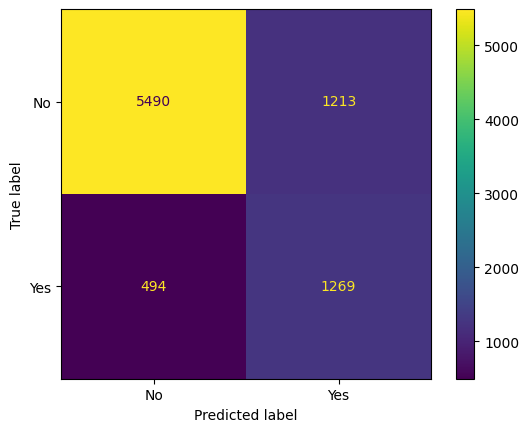

In [23]:
clf = (LogisticRegression(solver='liblinear',class_weight='balanced',random_state=42).fit(X_train, y_train))

pred = clf.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, pred)

In [24]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

          No       0.92      0.82      0.87      6703
         Yes       0.51      0.72      0.60      1763

    accuracy                           0.80      8466
   macro avg       0.71      0.77      0.73      8466
weighted avg       0.83      0.80      0.81      8466



**Висновок:**

Після переходу від випадкового розбиття до розбиття за останнім роком спостережень модель демонструє подібний рівень якості. Accuracy збільшилася з 0.79 до 0.80, а F1-score для класу No зріс із 0.85 до 0.87. Водночас Recall для класу Yes знизився з 0.76 до 0.72, тобто модель стала дещо гірше виявляти випадки, коли наступного дня буде дощ. Це пояснюється тим, що тестова вибірка тепер містить лише дані останнього року.

Використання розбиття за часом забезпечує більш реалістичну перевірку моделі та є рекомендованим підходом для задач прогнозування, де необхідно передбачати майбутні події на основі історичних даних.

Було проведено порівняння двох стратегій відновлення пропущених числових значень: заповнення середнім (mean) та медіаною (median). Отримані метрики класифікації виявилися однаковими. Це свідчить про те, що вибір між середнім і медіаною практично не впливає на якість побудованої моделі для цього набору даних.